In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Herramientas listas.")

Herramientas listas.


In [2]:
df = pd.read_csv('talentwell_data.csv')

ohe = OneHotEncoder(sparse_output=False, drop='first')
modalidad_encoded = ohe.fit_transform(df[['modalidad']])
nombres_columnas = ohe.get_feature_names_out(['modalidad']).tolist()
for i, col in enumerate(nombres_columnas):
    df[col] = modalidad_encoded[:, i]

features = [
    'horas_trabajo_dia', 'horas_sueno', 'reuniones_dia',
    'actividad_fisica_semanal', 'anios_experiencia',
    'modalidad_presencial', 'modalidad_remoto'
]

X = df[features]
y = df['riesgo_burnout']   # ← esto es lo que cambió: 0 = sin riesgo, 1 = burnout

# Antes de seguir: ¿cuántos casos de burnout hay?
print("=== ¿Cómo está distribuido el target? ===")
conteo = y.value_counts()
print(f"Sin riesgo (0): {conteo[0]} personas — {conteo[0]/len(y):.1%}")
print(f"Con burnout (1): {conteo[1]} personas — {conteo[1]/len(y):.1%}")


=== ¿Cómo está distribuido el target? ===
Sin riesgo (0): 1157 personas — 77.1%
Con burnout (1): 343 personas — 22.9%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y    # preserva la proporción de burnout en ambos conjuntos
)

print("=== Verificación de estratificación ===")
print(f"Tasa burnout en entrenamiento: {y_train.mean():.2%}")
print(f"Tasa burnout en prueba:        {y_test.mean():.2%}")
print("\nSi las dos proporciones son iguales (o casi): stratify funcionó correctamente.")

=== Verificación de estratificación ===
Tasa burnout en entrenamiento: 22.83%
Tasa burnout en prueba:        23.00%

Si las dos proporciones son iguales (o casi): stratify funcionó correctamente.


In [4]:
modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train, y_train)

print("Modelo logístico entrenado.")
print(f"\nIntercepto (β₀): {modelo_logistico.intercept_[0]:.4f}")
print("→ Negativo: sin considerar ninguna variable, el modelo parte desde 'sin riesgo'.")
print("→ Las features son las que empujan la probabilidad hacia arriba o hacia abajo.")

Modelo logístico entrenado.

Intercepto (β₀): -4.7431
→ Negativo: sin considerar ninguna variable, el modelo parte desde 'sin riesgo'.
→ Las features son las que empujan la probabilidad hacia arriba o hacia abajo.


In [5]:
y_pred_clase = modelo_logistico.predict(X_test)          # etiqueta: 0 o 1
y_pred_proba = modelo_logistico.predict_proba(X_test)    # dos columnas: P(sin riesgo), P(burnout)

# Tabla comparativa para las primeras 8 personas del conjunto de prueba
comparacion = pd.DataFrame({
    'Real':          y_test.values[:8],
    'Predicho':      y_pred_clase[:8],
    'P(sin riesgo)': y_pred_proba[:8, 0].round(3),
    'P(burnout)':    y_pred_proba[:8, 1].round(3)
})
print("=== Primeras 8 predicciones: etiqueta y probabilidad ===")
print(comparacion.to_string(index=False))
print("\nNota: P(sin riesgo) + P(burnout) siempre suma 1.0 — son complementarias.")

=== Primeras 8 predicciones: etiqueta y probabilidad ===
 Real  Predicho  P(sin riesgo)  P(burnout)
    0         0          0.998       0.002
    1         1          0.361       0.639
    0         0          0.916       0.084
    0         0          0.998       0.002
    0         0          0.967       0.033
    1         0          0.567       0.433
    1         1          0.216       0.784
    0         0          0.949       0.051

Nota: P(sin riesgo) + P(burnout) siempre suma 1.0 — son complementarias.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


df = pd.read_csv('talentwell_data.csv')

ohe = OneHotEncoder(sparse_output=False, drop='first')
modalidad_encoded = ohe.fit_transform(df[['modalidad']])
for i, col in enumerate(ohe.get_feature_names_out(['modalidad'])):
    df[col] = modalidad_encoded[:, i]

features = [
    'horas_trabajo_dia', 'horas_sueno', 'reuniones_dia',
    'actividad_fisica_semanal', 'anios_experiencia',
    'modalidad_presencial', 'modalidad_remoto'
]

X = df[features]
y = df['riesgo_burnout']  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_logistico = LogisticRegression(max_iter=1000, random_state=42)
modelo_logistico.fit(X_train, y_train)

y_pred_clase = modelo_logistico.predict(X_test)      
y_pred_proba = modelo_logistico.predict_proba(X_test)  

print("Modelo entrenado y predicciones listas.")
print(f"Intercepto (β₀): {modelo_logistico.intercept_[0]:.4f}  → negativo = arranca desde 'sin riesgo'")
print(f"\nPrimeras 5 personas — etiqueta y probabilidad:")
for i in range(20):
    print(f"  Real: {y_test.values[i]}  |  Predicho: {y_pred_clase[i]}  |  P(burnout): {y_pred_proba[i,1]:.3f}")

Modelo entrenado y predicciones listas.
Intercepto (β₀): -4.7431  → negativo = arranca desde 'sin riesgo'

Primeras 5 personas — etiqueta y probabilidad:
  Real: 0  |  Predicho: 0  |  P(burnout): 0.002
  Real: 1  |  Predicho: 1  |  P(burnout): 0.639
  Real: 0  |  Predicho: 0  |  P(burnout): 0.084
  Real: 0  |  Predicho: 0  |  P(burnout): 0.002
  Real: 0  |  Predicho: 0  |  P(burnout): 0.033
  Real: 1  |  Predicho: 0  |  P(burnout): 0.433
  Real: 1  |  Predicho: 1  |  P(burnout): 0.784
  Real: 0  |  Predicho: 0  |  P(burnout): 0.051
  Real: 1  |  Predicho: 1  |  P(burnout): 0.839
  Real: 0  |  Predicho: 0  |  P(burnout): 0.199
  Real: 1  |  Predicho: 1  |  P(burnout): 0.735
  Real: 1  |  Predicho: 1  |  P(burnout): 0.908
  Real: 0  |  Predicho: 0  |  P(burnout): 0.016
  Real: 0  |  Predicho: 1  |  P(burnout): 0.537
  Real: 0  |  Predicho: 0  |  P(burnout): 0.001
  Real: 0  |  Predicho: 0  |  P(burnout): 0.151
  Real: 0  |  Predicho: 0  |  P(burnout): 0.362
  Real: 0  |  Predicho: 0  |  

In [3]:
acc = accuracy_score(y_test, y_pred_clase)
baseline = (y_test == 0).mean()

print(f"Accuracy del modelo logístico:  {acc:.1%}")
print(f"Accuracy del modelo estúpido:   {baseline:.1%}  ← siempre dice 'sin riesgo', nunca aprende nada")
print(f"Ganancia real del modelo:       {(acc - baseline)*100:.1f} puntos porcentuales")
print()
print("=== Reporte completo por clase ===")
print(classification_report(y_test, y_pred_clase, target_names=['Sin riesgo', 'Burnout']))

Accuracy del modelo logístico:  83.0%
Accuracy del modelo estúpido:   77.0%  ← siempre dice 'sin riesgo', nunca aprende nada
Ganancia real del modelo:       6.0 puntos porcentuales

=== Reporte completo por clase ===
              precision    recall  f1-score   support

  Sin riesgo       0.88      0.91      0.89       231
     Burnout       0.65      0.57      0.60        69

    accuracy                           0.83       300
   macro avg       0.76      0.74      0.75       300
weighted avg       0.82      0.83      0.83       300



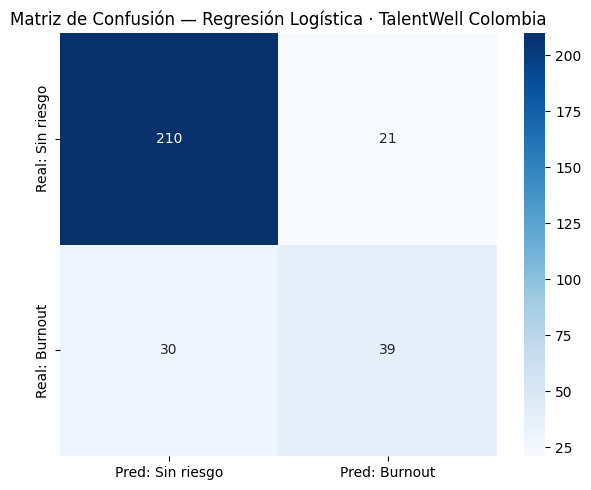

Verdaderos Negativos (VN):  210  — Dijo 'sin riesgo' y era correcto ✓
Falsos Positivos    (FP):   21  — Dijo 'burnout' pero no lo había  (alarma falsa)
Falsos Negativos    (FN):   30  — Dijo 'sin riesgo' pero SÍ había burnout ⚠
Verdaderos Positivos(VP):   39  — Dijo 'burnout' y era correcto ✓

Recall Burnout = VP / (VP + FN) = 39 / (39 + 30) = 56.52%


In [4]:
cm = confusion_matrix(y_test, y_pred_clase)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Sin riesgo', 'Pred: Burnout'],
    yticklabels=['Real: Sin riesgo', 'Real: Burnout'],
    ax=ax
)
ax.set_title('Matriz de Confusión — Regresión Logística · TalentWell Colombia', fontsize=12)
plt.tight_layout()
plt.show()

vn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
vp = cm[1, 1]

print(f"Verdaderos Negativos (VN): {vn:>4}  — Dijo 'sin riesgo' y era correcto ✓")
print(f"Falsos Positivos    (FP): {fp:>4}  — Dijo 'burnout' pero no lo había  (alarma falsa)")
print(f"Falsos Negativos    (FN): {fn:>4}  — Dijo 'sin riesgo' pero SÍ había burnout ⚠")
print(f"Verdaderos Positivos(VP): {vp:>4}  — Dijo 'burnout' y era correcto ✓")
print()
print(f"Recall Burnout = VP / (VP + FN) = {vp} / ({vp} + {fn}) = {vp/(vp+fn):.2%}")

In [5]:
coef_logistico = pd.DataFrame({
    'feature':     features,
    'coeficiente': modelo_logistico.coef_[0]
}).sort_values('coeficiente', ascending=False)

print("=== Lo que aprendió el modelo logístico ===")
print(coef_logistico.to_string(index=False))
print()
print("  + positivo → empuja la probabilidad de burnout hacia arriba")
print("  − negativo → la empuja hacia abajo (factor protector)")

=== Lo que aprendió el modelo logístico ===
                 feature  coeficiente
       horas_trabajo_dia     0.752930
        modalidad_remoto     0.664895
           reuniones_dia     0.567972
       anios_experiencia    -0.005230
actividad_fisica_semanal    -0.329121
    modalidad_presencial    -0.618422
             horas_sueno    -0.826707

  + positivo → empuja la probabilidad de burnout hacia arriba
  − negativo → la empuja hacia abajo (factor protector)
